In [84]:
from pathlib import Path
from functools import reduce
import pandas as pd
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations
from scipy.stats import chi2_contingency
from scipy import stats
from scipy import stats
from statsmodels.discrete.truncated_model import TruncatedLFNegativeBinomialP, TruncatedLFPoisson

In [85]:
# Load and merge files
ELSA_DIR = Path("../data/elsa")
files = sorted(ELSA_DIR.glob("*.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df["idauniq"] = pd.to_numeric(df["idauniq"], errors="coerce").astype("Int64")
    dfs.append(df.drop_duplicates(subset="idauniq"))

base, *rest = dfs
rest = [d.drop(columns=["hhid", "xwgt", "gor"], errors="ignore") for d in rest]

df_merged = reduce(lambda l, r: pd.merge(l, r, on="idauniq", how="outer"), [base] + rest)
print(df_merged.shape)

(5000, 34)


In [86]:
# Percent of individuals with care need in the sample

len(df_merged[df_merged["has_any_care_needs"] == 1])/len(df_merged)

0.3328

In [87]:
# Define variables of interest

OUTCOME = "has_any_care_needs"
 
predictor_groups = {
    "Partner status": ["partner_does_not_have_partner"],                         # ref: has partner
    "Wealth quintile": ["wealth_q2", "wealth_q3", "wealth_q4", "wealth_q5"],      # ref: Q1
    "Homeowner": ["homeowner"],                                                  # ref: non-homeowner
    "Sex": ["male"],                                                             # ref: female
    "Age group": ["age_70_74", "age_75_79", "age_80_84", "age_85_plus"],          # ref: 65-69
    "Self-rated health": ["health_good_health", "health_fair_health",
                          "health_bad_health"],                                  # ref: very good
    "Ethnicity": ["ethnicity_non_white"],                                        # ref: White
    "Country of birth": ["non_uk_born"],                                          # ref: UK born
}
predictors = [v for cols in predictor_groups.values() for v in cols] 
 

In [109]:
# Build logit model

data = (
    df_merged[predictors + [OUTCOME]]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
X = sm.add_constant(data[predictors], has_constant="add").astype(float)
y = data[OUTCOME].astype(float)
assert y.nunique() == 2, f"{OUTCOME} is not binary: {sorted(y.unique())}"
 
m1 = sm.Logit(y, X).fit(maxiter=1000, disp=False)
 
ci = np.exp(m1.conf_int())
or_table = pd.DataFrame({
    "OR": np.exp(m1.params),
    "CI_lower": ci[0],
    "CI_upper": ci[1],
    "p": m1.pvalues,
})
 
n_excluded = len(df_merged) - int(m1.nobs)
or_table.round({"OR": 3, "CI_lower": 3, "CI_upper": 3, "p": 4})
 
 
p_hat = m1.predict()
auc = roc_auc_score(y, p_hat)
 
fit_stats = pd.Series({
    "LR_chi2": m1.llr,
    "df": int(m1.df_model),
    "LR_p": m1.llr_pvalue,
    "McFadden_R2": m1.prsquared,
    "AUC": auc,
}, name="Any care need")
fit_stats
 

LR_chi2         1.237692e+03
df              1.600000e+01
LR_p           1.208023e-253
McFadden_R2     2.026865e-01
AUC             7.952017e-01
Name: Any care need, dtype: float64

In [91]:
or_table

,OR,CI_lower,CI_upper,p
const,0.247388,0.179839,0.340311,9.105642e-18
partner_does_not_have_partner,1.120118,0.959045,1.308244,1.521299e-01
wealth_q2,0.669372,0.521194,0.859677,1.664786e-03
wealth_q3,0.650612,0.504223,0.839501,9.491223e-04
wealth_q4,0.622837,0.480065,0.808068,3.649489e-04
wealth_q5,0.517376,0.394525,0.678481,1.893358e-06
homeowner,0.695272,0.561346,0.861151,8.707131e-04
male,0.840142,0.727217,0.970603,1.802496e-02
age_70_74,1.093872,0.881733,1.357050,4.146767e-01
age_75_79,1.418138,1.149869,1.748995,1.093860e-03


In [110]:

census = {
    "Sex": ["male"],
    "Age group": predictor_groups["Age group"],
    "Partner status": predictor_groups["Partner status"],
    "Self-rated health": predictor_groups["Self-rated health"],
    "Ethnicity": predictor_groups["Ethnicity"],
    "Country of birth": predictor_groups["Country of birth"],
}
census_cols = [c for cols in census.values() for c in cols]

m_census = sm.Logit(y, sm.add_constant(data[census_cols])).fit(disp=False)
ci_c = np.exp(m_census.conf_int())

tests, ors = [], []
for group, cols in census.items():
    others = [c for c in census_cols if c not in cols]
    m_without = sm.Logit(y, sm.add_constant(data[others])).fit(disp=False)
    lr = 2 * (m_census.llf - m_without.llf)
    tests.append({"Variable": group, "df": len(cols), "LR_chi2": lr, "p": stats.chi2.sf(lr, len(cols))})
    for c in cols:
        ors.append({"Variable": group, "Category": c, "OR": np.exp(m_census.params[c]),
                    "CI_lower": ci_c.loc[c, 0], "CI_upper": ci_c.loc[c, 1], "p": m_census.pvalues[c]})

display(pd.DataFrame(tests).set_index("Variable").round({"LR_chi2": 2, "p": 4}))
pd.DataFrame(ors).set_index(["Variable", "Category"]).round({"OR": 4, "CI_lower": 4, "CI_upper": 4, "p": 4})

,df,LR_chi2,p
Variable,,,
Sex,1,6.07,0.0137
Age group,4,221.19,0.0000
Partner status,1,12.73,0.0004
Self-rated health,3,824.28,0.0000
Ethnicity,1,0.01,0.9077
Country of birth,1,0.89,0.3462


OR  CI_lower  CI_upper  \
Variable          Category                                                     
Sex               male                            0.8355    0.7241    0.9641   
Age group         age_70_74                       1.0583    0.8555    1.3091   
                  age_75_79                       1.3541    1.1008    1.6658   
                  age_80_84                       2.1428    1.7038    2.6950   
                  age_85_plus                     4.5587    3.6090    5.7583   
Partner status    partner_does_not_have_partner   1.3070    1.1288    1.5133   
Self-rated health health_good_health              1.9703    1.6400    2.3672   
                  health_fair_health              5.4551    4.5094    6.5992   
                  health_bad_health              23.6383   18.0447   30.9659   
Ethnicity         ethnicity_non_white             1.0209    0.7195    1.4485   
Country of birth  non_uk_born                     0.8971    0.7151    1.1255   

                                                      p  
Variable          Category                               
Sex               male                           0.0139  
Age group         age_70_74                      0.6017  
                  age_75_79                      0.0041  
                  age_80_84                      0.0000  
                  age_85_plus                    0.0000  
Partner status    partner_does_not_have_partner  0.0003  
Self-rated health health_good_health             0.0000  
                  health_fair_health             0.0000  
                  health_bad_health              0.0000  
Ethnicity         ethnicity_non_white            0.9076  
Country of birth  non_uk_born                    0.3480

In [101]:
# Test colinearity


Xp = X[predictors]
corr = Xp.corr()
R = corr.values

vif = pd.Series(
    [variance_inflation_factor(X.values, X.columns.get_loc(v)) for v in predictors],
    index=predictors, name="VIF",
)

rows = []
for group, cols in predictor_groups.items():
    idx = [predictors.index(c) for c in cols]
    rest = [i for i in range(len(predictors)) if i not in idx]
    g = (np.linalg.det(R[np.ix_(idx, idx)])
         * np.linalg.det(R[np.ix_(rest, rest)])
         / np.linalg.det(R))
    rows.append({"Variable": group, "df": len(cols), "GVIF": g,
                 "GVIF^(1/(2*df))": g ** (1 / (2 * len(cols)))})
gvif = pd.DataFrame(rows).set_index("Variable")

# (c) |r| > 0.5 between indicators of different variables
group_of = {v: g for g, cols in predictor_groups.items() for v in cols}
pairs = pd.DataFrame(
    [(a, b, corr.loc[a, b]) for a, b in combinations(predictors, 2)
     if group_of[a] != group_of[b] and abs(corr.loc[a, b]) > 0.5],
    columns=["Variable 1", "Variable 2", "r"],
)

# (d) Condition number of the standardised predictor matrix
kappa = np.linalg.cond(((Xp - Xp.mean()) / Xp.std(ddof=0)).values)

display(vif.round(3).to_frame())
print("VIF > 5:", list(vif.index[vif > 5]) or "none")
display(gvif.round(3))
print("GVIF^(1/(2df)) > 2.24:", list(gvif.index[gvif["GVIF^(1/(2*df))"] > np.sqrt(5)]) or "none")
print(pairs.round(3).to_string(index=False) if len(pairs) else "No cross-variable pairs with |r| > 0.5")
print(f"Condition number (standardised) = {kappa:.2f}")

,VIF
partner_does_not_have_partner,1.221
wealth_q2,2.327
wealth_q3,2.660
wealth_q4,2.800
wealth_q5,2.838
homeowner,1.250
male,1.046
age_70_74,1.529
age_75_79,1.546
age_80_84,1.401


VIF > 5: none


,df,GVIF,GVIF^(1/(2*df))
Variable,,,
Partner status,1,1.221,1.105
Wealth quintile,4,1.341,1.037
Homeowner,1,1.250,1.118
Sex,1,1.046,1.023
Age group,4,1.109,1.013
Self-rated health,3,1.118,1.019
Ethnicity,1,1.343,1.159
Country of birth,1,1.325,1.151


GVIF^(1/(2df)) > 2.24: none
No cross-variable pairs with |r| > 0.5
Condition number (standardised) = 4.01


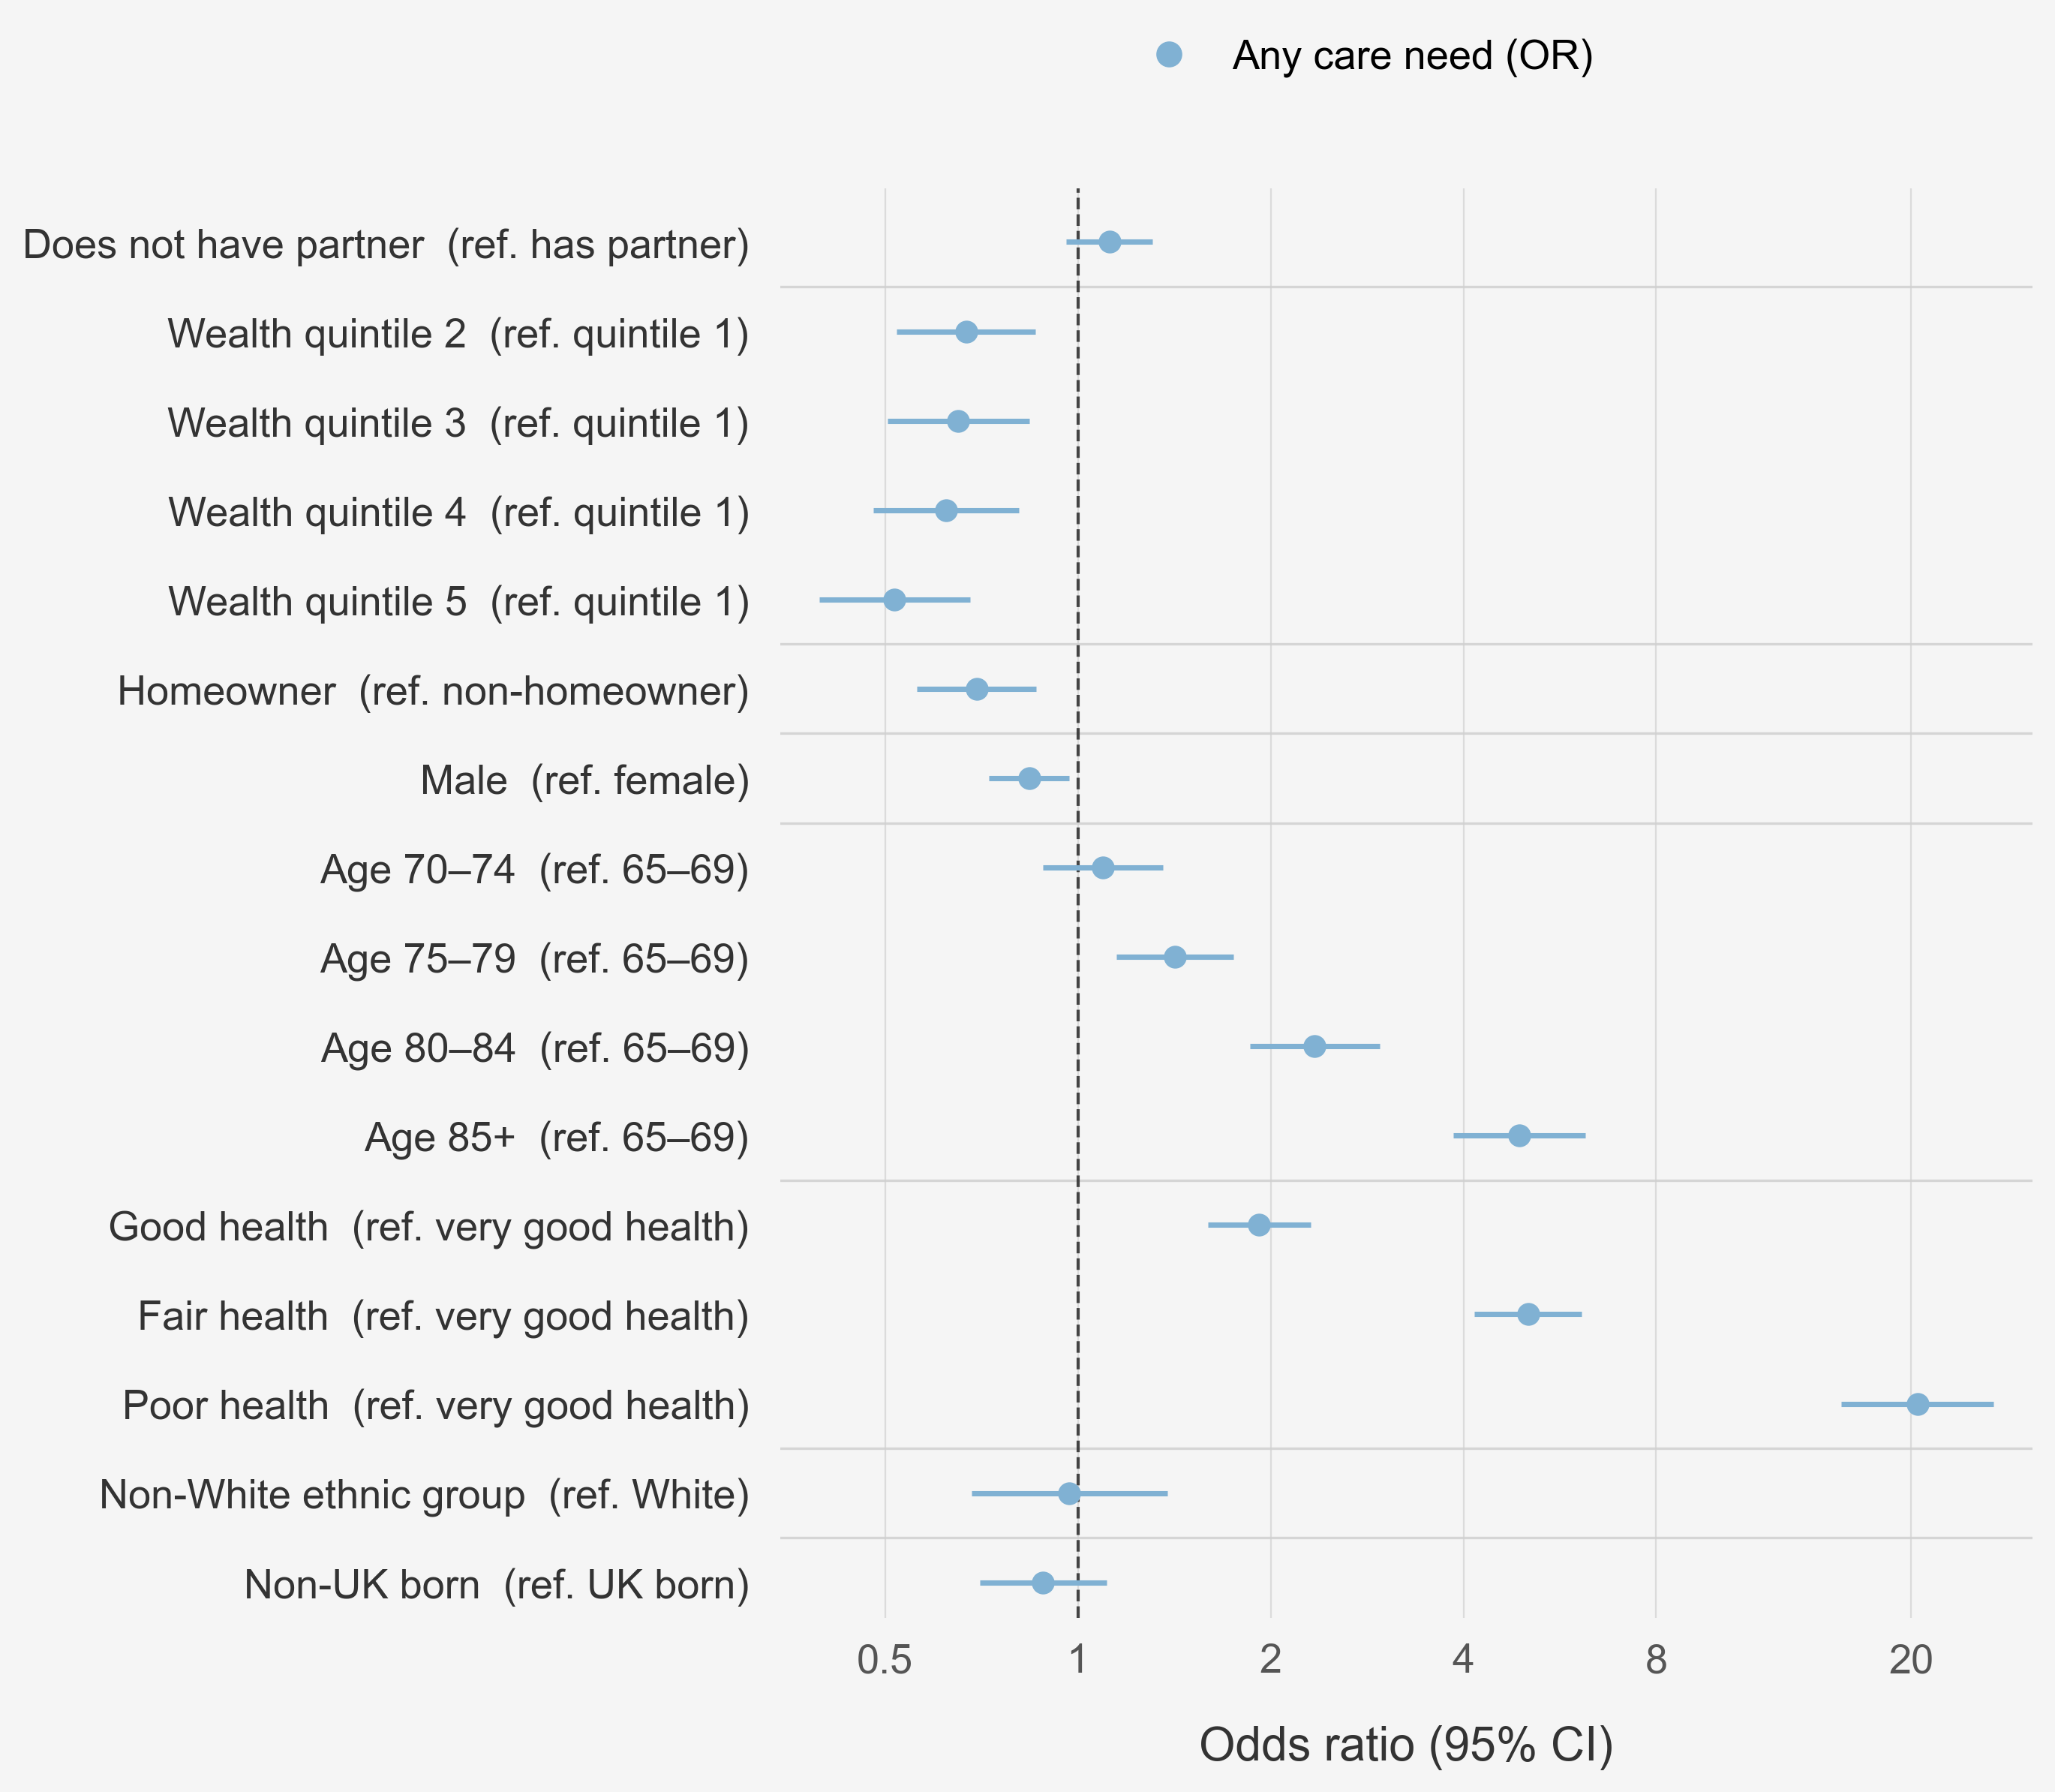

In [104]:
# Generate chart

BACKGROUND, TEXT, MUTED, GRID, OR_COLOUR = "#F5F5F5", "#333333", "#555555", "#D0D0D0", "#80B1D3"

mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.labelcolor": TEXT,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.color": MUTED,
    "ytick.color": TEXT,
    "legend.fontsize": 13,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

PREDICTOR_BLOCKS = {
    "Partnership": ["partner_does_not_have_partner"],
    "Wealth": ["wealth_q2", "wealth_q3", "wealth_q4", "wealth_q5"],
    "Housing": ["homeowner"],
    "Sex": ["male"],
    "Age": ["age_70_74", "age_75_79", "age_80_84", "age_85_plus"],
    "Self-rated health": ["health_good_health", "health_fair_health", "health_bad_health"],
    "Ethnicity": ["ethnicity_non_white"],
    "Country of birth": ["non_uk_born"],
}

LABELS = {
    "partner_does_not_have_partner": "Does not have partner  (ref. has partner)",
    "wealth_q2": "Wealth quintile 2  (ref. quintile 1)",
    "wealth_q3": "Wealth quintile 3  (ref. quintile 1)",
    "wealth_q4": "Wealth quintile 4  (ref. quintile 1)",
    "wealth_q5": "Wealth quintile 5  (ref. quintile 1)",
    "homeowner": "Homeowner  (ref. non-homeowner)",
    "male": "Male  (ref. female)",
    "age_70_74": "Age 70–74  (ref. 65–69)",
    "age_75_79": "Age 75–79  (ref. 65–69)",
    "age_80_84": "Age 80–84  (ref. 65–69)",
    "age_85_plus": "Age 85+  (ref. 65–69)",
    "health_good_health": "Good health  (ref. very good health)",
    "health_fair_health": "Fair health  (ref. very good health)",
    "health_bad_health": "Poor health  (ref. very good health)",
    "ethnicity_non_white": "Non-White ethnic group  (ref. White)",
    "non_uk_born": "Non-UK born  (ref. UK born)",
}

coef_names = [v for cols in PREDICTOR_BLOCKS.values() for v in cols]
separators = np.cumsum([len(c) for c in PREDICTOR_BLOCKS.values()])[:-1] - 0.5

ci = np.exp(m1.conf_int())
or_plot = pd.DataFrame({
    "OR": np.exp(m1.params),
    "CI_lower": ci[0],
    "CI_upper": ci[1],
}).loc[coef_names]
or_plot["label"] = [LABELS[v] for v in coef_names]
assert (or_plot[["OR", "CI_lower", "CI_upper"]] > 0).all().all()

x_min = max(0.05, min(0.50, or_plot["CI_lower"].min() / 1.15))
x_max = max(2.00, or_plot["CI_upper"].max() * 1.15)
x_ticks = [t for t in (0.05, 0.10, 0.25, 0.50, 1, 2, 4, 8, 20, 50, 100, 200) if x_min <= t <= x_max]


ypos = np.arange(len(coef_names))

fig, ax = plt.subplots(figsize=(10.4, 8.7), facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)
fig.subplots_adjust(left=0.43, right=0.965, bottom=0.13, top=0.86)

ax.errorbar(
    or_plot["OR"], ypos,
    xerr=[or_plot["OR"] - or_plot["CI_lower"], or_plot["CI_upper"] - or_plot["OR"]],
    fmt="o", markersize=7.3, markeredgewidth=0, color=OR_COLOUR,
    elinewidth=1.7, capsize=3, capthick=1.4, zorder=5,
)
ax.axvline(1, color=TEXT, linestyle="--", linewidth=1.0, alpha=0.9, zorder=3)
for s in separators:
    ax.axhline(s, color=GRID, linewidth=0.8, alpha=0.85, zorder=2)

ax.set_xscale("log")
ax.set_xlim(x_min, x_max)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{t:g}" for t in x_ticks])
ax.xaxis.set_minor_locator(NullLocator())
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel("Odds ratio (95% CI)", fontsize=15, color=TEXT, labelpad=14)

ax.set_yticks(ypos)
ax.set_yticklabels(or_plot["label"], fontsize=13, color=TEXT)
ax.set_ylim(len(coef_names) - 0.6, -0.6)

ax.grid(axis="x", color=GRID, linewidth=0.55, alpha=0.7)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", length=0)
ax.tick_params(axis="x", pad=8)
ax.tick_params(axis="y", pad=10)

fig.legend(
    handles=[Line2D([0], [0], marker="o", linestyle="none", markersize=7.3,
                    color=OR_COLOUR, label="Any care need (OR)")],
    loc="upper center", bbox_to_anchor=(0.68, 0.945), frameon=False,
    fontsize=13, handlelength=1.5, borderaxespad=0,
)

for ext in ("pdf", "png"):
    fig.savefig(f"../figures/any_care_need_odds_ratios.{ext}", bbox_inches="tight", facecolor=BACKGROUND)
plt.show()